# Classification

## 1. Dataset Loading and Audit

This section loads the Adult Income dataset and performs an initial audit of
the dataset, including its shape, data types, missing values, duplicates,
and target distribution.

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
url = "https://raw.githubusercontent.com/snehitha-araveti/ML-Capstone-Project-2026/main/data/adult.csv"

df = pd.read_csv(url)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


### Data Types

In [4]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


### Missing Value Identification

In [5]:
df = df.replace("?", np.nan)

### Missing Value Summary

In [6]:
# Display missing-value count for each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


### Columns Containing Missing Values

In [7]:
print("Columns with Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columns with Missing Values:
workclass         1836
occupation        1843
native.country     583
dtype: int64


### Target Class Distribution

In [8]:
# Target/Class Distribution
print("Target Distribution:")
print(df["income"].value_counts())

print("\nTarget Distribution (%):")
print(df["income"].value_counts(normalize=True) * 100)

Target Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target Distribution (%):
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


### Observation – Dataset Audit

The dataset contains a combination of numerical and categorical features, with `income` as the target variable. Missing values are present in some categorical features and are represented as `NaN` after replacing the original `?` markers. The target variable contains two income classes, with the `<=50K` class occurring more frequently than the `>50K` class.

## A2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distributions of the features, relationships among numerical variables, target-class balance, and potential relationships between selected features and the income class.

### Feature Identification

In [9]:
# Separate input features from target

target = "income"

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

# Remove target from categorical features
categorical_features.remove(target)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Categorical Features:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


C:\Users\Prakash\AppData\Local\Temp\ipykernel_8520\2206283461.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include="object").columns.tolist()


### Numerical Feature Distributions

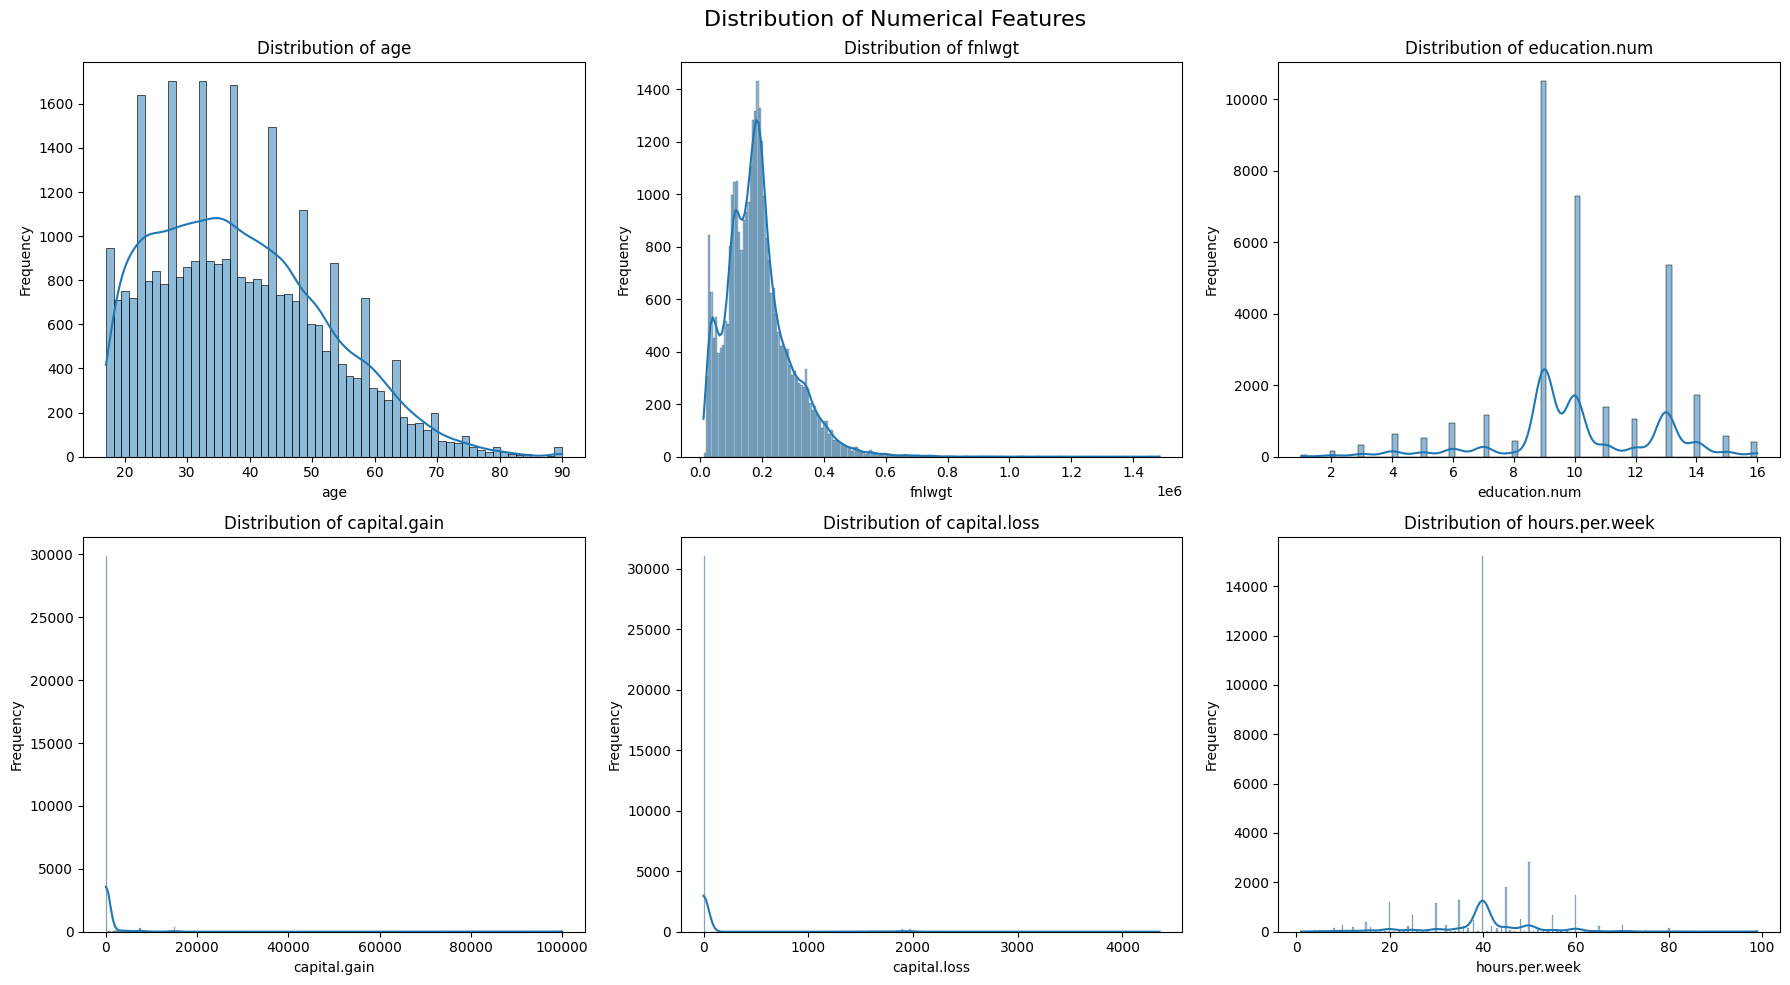

In [10]:
# Distribution plots for numerical features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i])

    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation – Numerical Feature Distributions

- **Age:** The distribution is concentrated mainly among working-age adults, with fewer observations at very young and very old ages.
- **fnlwgt:** The feature shows a wide and right-skewed distribution, indicating substantial variation in the sampling weights.
- **education.num:** The values are concentrated around the middle education levels, with fewer observations at the lowest and highest levels.
- **capital.gain:** Most observations have zero capital gain, while a small number of observations have substantially higher values, indicating strong right skewness.
- **capital.loss:** Similar to capital gain, most observations have zero capital loss, while relatively few observations have larger values.
- **hours.per.week:** Most observations are concentrated around the typical full-time working range, with fewer observations at very low or very high working hours.

### Categorical Feature Distributions

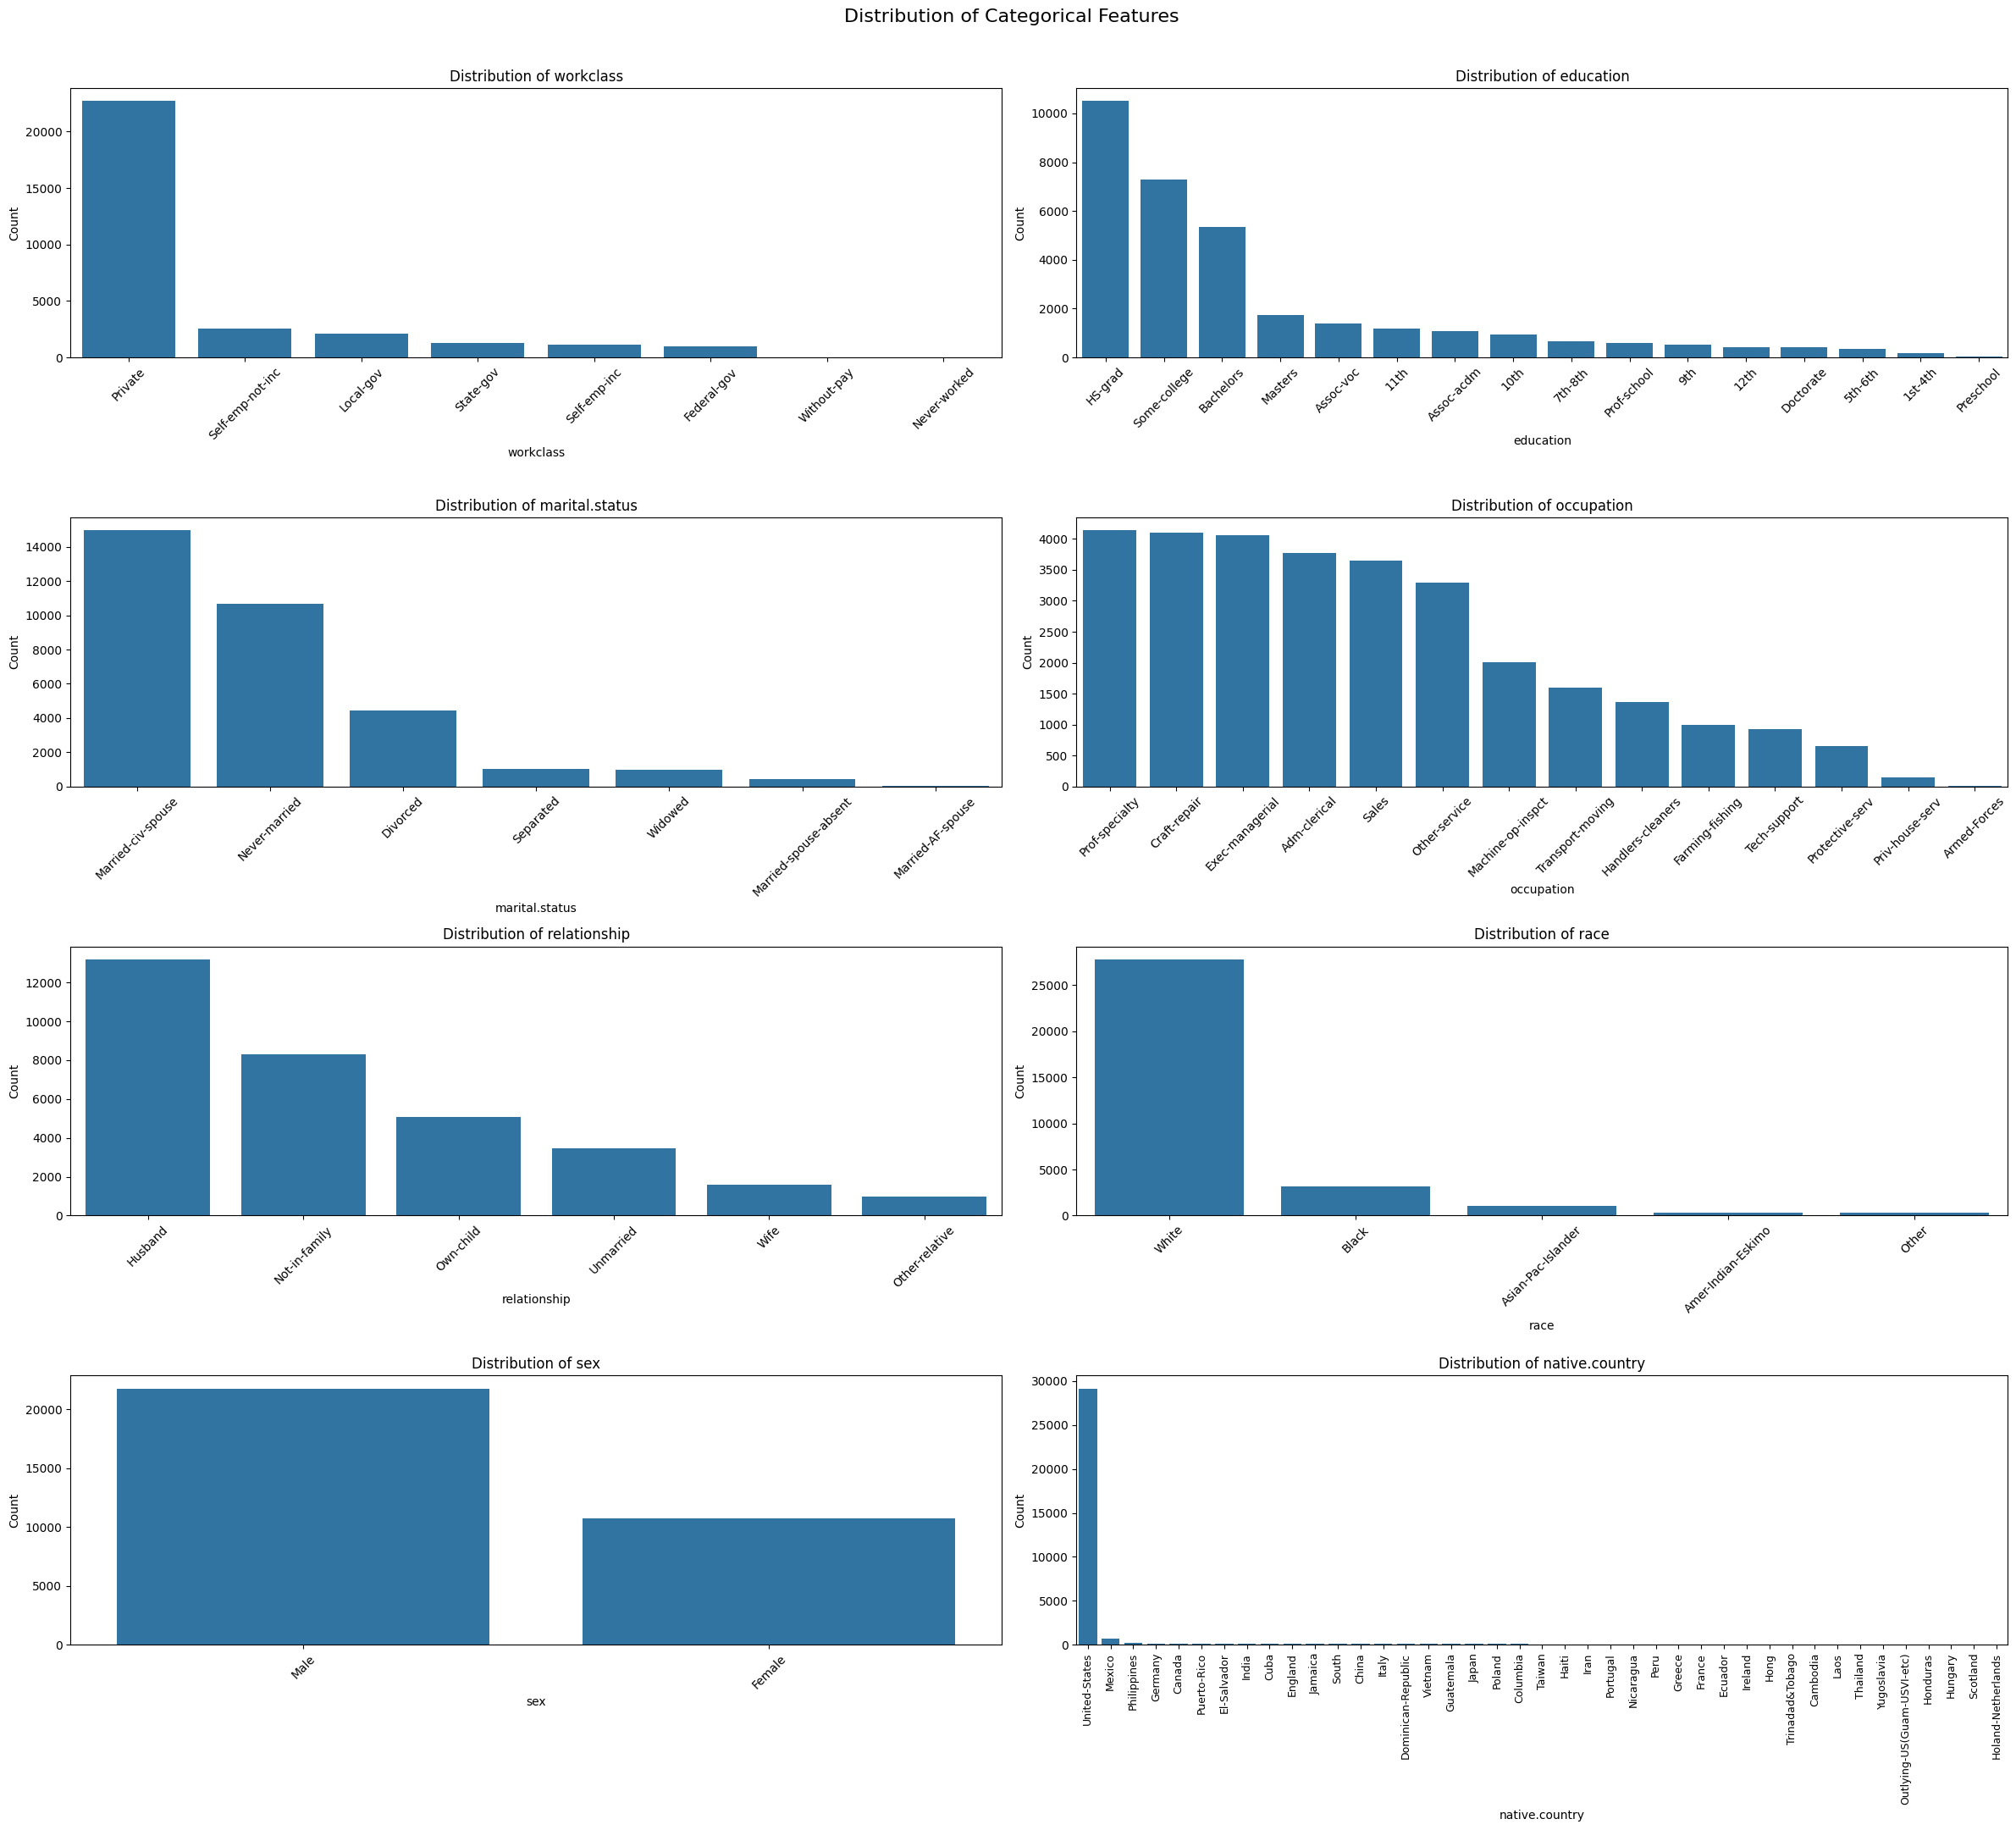

In [11]:
# Distribution plots for categorical features

fig, axes = plt.subplots(4, 2, figsize=(24, 22))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

    # Rotate category labels
    if feature == "native.country":
        axes[i].tick_params(axis="x", rotation=90, labelsize=9)
    else:
        axes[i].tick_params(axis="x", rotation=45)

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Observation – Categorical Feature Distributions

- **Workclass:** The dataset is dominated by the Private workclass, while several other workclass categories contain considerably fewer observations.
- **Education:** A few education categories account for a large proportion of the observations, while higher-level categories are less frequent.
- **Marital Status:** Married-civil-spouse is the most frequent category, followed by several unmarried or previously married categories.
- **Occupation:** Some occupations are substantially more common than others, showing an uneven distribution across occupational groups.
- **Relationship:** Husband and Not-in-family represent prominent groups, while some relationship categories have relatively few observations.
- **Race:** The White category forms the majority of observations, with the remaining racial categories representing smaller groups.
- **Sex:** The dataset contains more observations for Male than Female.
- **Native Country:** United-States is overwhelmingly the most frequent category, while many other countries have relatively small numbers of observations.

### Correlation Heatmap

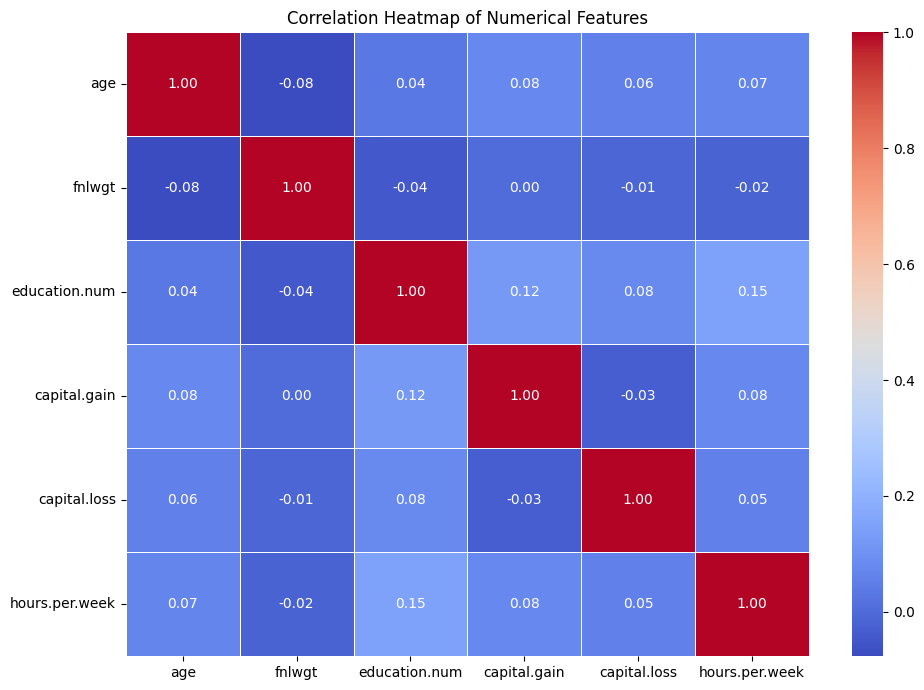

In [12]:
# Correlation heatmap for numerical features

plt.figure(figsize=(10, 7))

correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### Observation – Correlation Heatmap

The correlation heatmap shows the strength and direction of linear relationships among the numerical features. Most feature pairs exhibit weak correlations, while some variables show comparatively stronger relationships. The heatmap also indicates that the numerical features do not all provide redundant information, suggesting that multiple features may contribute different information to the classification task.

### Target Distribution

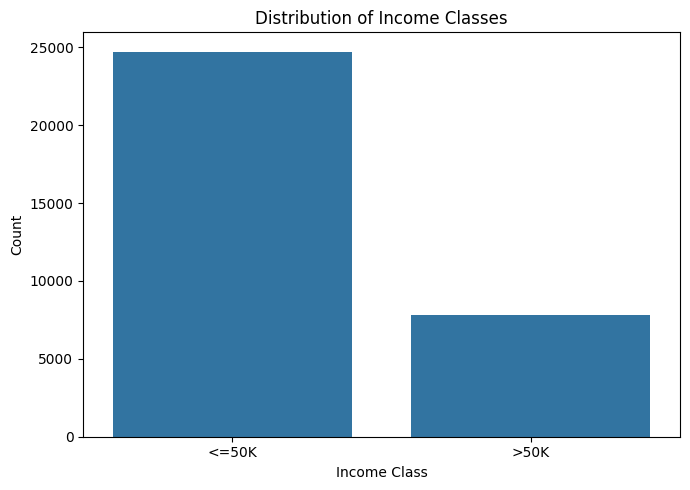

In [13]:
# Target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="income",
    order=df["income"].value_counts().index
)

plt.title("Distribution of Income Classes")
plt.xlabel("Income Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation – Income Class Distribution

The target variable is not evenly distributed across the two income classes. The `<=50K` class contains substantially more observations than the `>50K` class, indicating class imbalance in the dataset. Therefore, model evaluation should consider metrics such as precision, recall, weighted F1-score, and the confusion matrix rather than relying only on accuracy.

### Income Class Representation for Visualization

In [14]:
# Create numerical representation of income for visualization

income_numeric = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

### Age vs Income Class

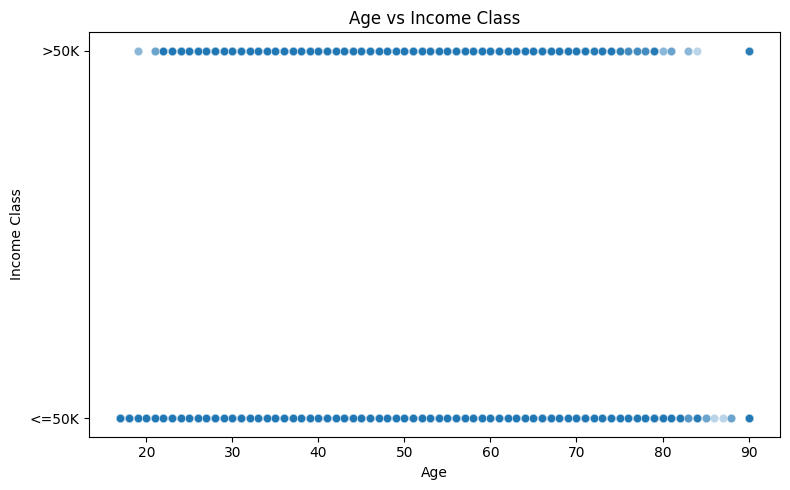

In [15]:
# Scatter plot: Age vs Income

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["age"],
    y=income_numeric,
    alpha=0.3
)

plt.title("Age vs Income Class")
plt.xlabel("Age")
plt.ylabel("Income Class")
plt.yticks([0, 1], ["<=50K", ">50K"])

plt.tight_layout()
plt.show()

### Observation – Age vs Income

The scatter plot shows that both income classes occur across a wide range of ages. However, the distribution of observations suggests that the higher-income class becomes more prominent among older working-age individuals. This indicates that age may provide useful information for distinguishing between the two income classes.

### Hours per Week vs Income Class

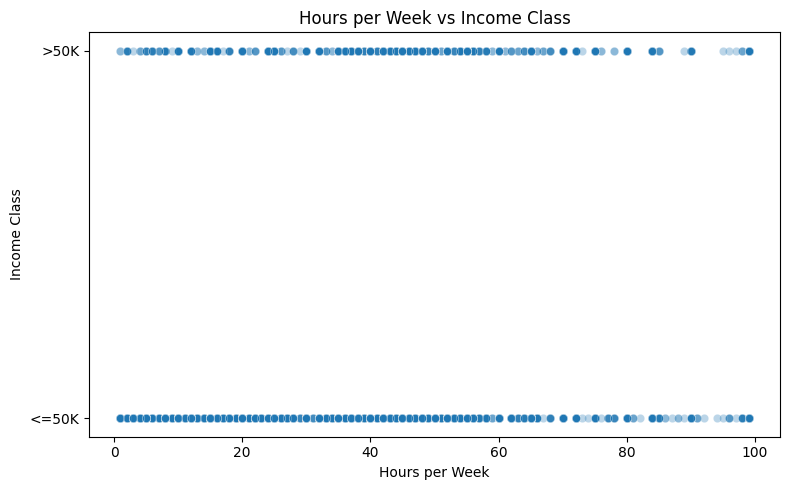

In [16]:
# Scatter plot: Hours per Week vs Income

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["hours.per.week"],
    y=income_numeric,
    alpha=0.3
)

plt.title("Hours per Week vs Income Class")
plt.xlabel("Hours per Week")
plt.ylabel("Income Class")
plt.yticks([0, 1], ["<=50K", ">50K"])

plt.tight_layout()
plt.show()

### Observation – Hours per Week vs Income

The scatter plot shows that both income classes occur across different working-hour levels. The higher-income class appears more frequently at higher working hours, although there is considerable overlap between the two classes. This suggests that hours worked per week may provide useful predictive information, but it is unlikely to be sufficient on its own for accurate classification.

## A3. EDA Insights

The exploratory analysis shows that the Adult dataset contains both numerical and categorical features with varied distributions. Several numerical features are skewed, particularly `capital.gain` and `capital.loss`, while categorical variables show uneven category frequencies. The target variable is imbalanced, with more observations belonging to the `<=50K` class. The visualizations of age and hours worked per week also indicate that these features may provide useful information for distinguishing between income classes, although there is considerable overlap between the two groups.

## B1. Data Cleaning

Data cleaning is performed to identify and handle missing values, duplicate records, and potential outliers while preserving useful information in the dataset.

### B1.1 Missing Value Analysis and Treatment

In [17]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [18]:
# Fill missing categorical values using the mode
for feature in categorical_features:
    df[feature] = df[feature].fillna(df[feature].mode()[0])

print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


### Observation – Missing Value Treatment

Missing values were found in the categorical features `workclass`, `occupation`, and `native.country`. Since these features are categorical, the missing values were replaced with the mode of their respective columns. Mode imputation was chosen to preserve the available records while providing a simple and suitable treatment for categorical missing values.

### B1.2 Duplicate Records

In [19]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 24


In [20]:
# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("Number of duplicate records after treatment:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate records after treatment: 0
Dataset shape after removing duplicates: (32537, 15)


### Observation – Duplicate Records

A total of 24 duplicate records were identified in the dataset. These duplicate records were removed because they do not provide additional information and could give repeated observations unnecessary influence during model training. After treatment, no duplicate records remained.

### B1.3 Outlier Detection and Treatment

Outliers in the numerical features are identified using the Interquartile Range (IQR) method. The detected values are reviewed before treatment to avoid removing observations that may contain meaningful information.

In [21]:
# Check for outliers using the IQR method

outlier_counts = {}

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_counts[feature] = (
        ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
    )

print("Number of outliers detected:")
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")

Number of outliers detected:
age: 142
fnlwgt: 993
education.num: 1193
capital.gain: 2712
capital.loss: 1519
hours.per.week: 9002


In [22]:
# Apply IQR-based capping to numerical features

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[feature] = df[feature].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed using IQR-based capping.")

Outlier treatment completed using IQR-based capping.


In [23]:
# Verify that values are within the IQR-based bounds

remaining_outliers = {}

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    remaining_outliers[feature] = (
        ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
    )

print("Outliers after treatment:")
for feature, count in remaining_outliers.items():
    print(f"{feature}: {count}")

Outliers after treatment:
age: 0
fnlwgt: 0
education.num: 0
capital.gain: 0
capital.loss: 0
hours.per.week: 0


### Observation – Outlier Detection and Treatment

Outliers were identified using the Interquartile Range (IQR) method. The detected extreme values were treated using IQR-based capping rather than removing complete observations. This approach preserves the available data while reducing the influence of extreme values on the classification models. After treatment, the IQR-based outlier check showed 0 remaining outliers across all numerical features.

## B2. Encoding, Scaling and Train/Test Split

The features are separated into input variables and the target variable. Categorical features are encoded using one-hot encoding, while numerical features are standardized. The dataset is divided into training and testing sets using a stratified split to preserve the original class distribution. The preprocessing transformations are fitted only on the training data to prevent data leakage.

In [24]:
# Separate features and target

X = df.drop("income", axis=1)
y = df["income"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32537, 14)
Target shape: (32537,)


In [25]:
from sklearn.model_selection import train_test_split

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (26029, 14)
Testing set shape: (6508, 14)

Training target distribution:
income
<=50K    0.759076
>50K     0.240924
Name: proportion, dtype: float64

Testing target distribution:
income
<=50K    0.759066
>50K     0.240934
Name: proportion, dtype: float64


### Observation – Stratified Train/Test Split

The dataset was divided into training and testing sets using an 80:20 split with `random_state=42`. Stratification was applied using the target variable so that both sets maintain a similar distribution of the two income classes.

### Categorical Encoding and Numerical Scaling

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (26029, 104)
Processed testing shape: (6508, 104)


### Observation – Encoding and Scaling

Categorical features were converted into numerical representations using one-hot encoding, while numerical features were standardized using `StandardScaler`. The preprocessing was fitted only on the training data and then applied to the testing data, preventing information from the test set from influencing the preprocessing stage.

## B3. Feature Engineering

Feature engineering is performed to create an additional feature from the existing variables. The new feature is designed to provide a more meaningful representation of the individual's capital-related information and may help the classification models distinguish between the income classes.

In [27]:
# Create an engineered feature: Net Capital

df["capital.net"] = df["capital.gain"] - df["capital.loss"]

print("Engineered feature created successfully.")
print(df[["capital.gain", "capital.loss", "capital.net"]].head())

Engineered feature created successfully.
   capital.gain  capital.loss  capital.net
0             0             0            0
1             0             0            0
2             0             0            0
3             0             0            0
4             0             0            0


### Justification for the Engineered Feature

The `capital.net` feature is created by subtracting `capital.loss` from `capital.gain`.


capital.net = capital.gain - capital.loss


This feature combines the information from `capital.gain` and `capital.loss` into a single numerical feature representing the net capital amount. It may help the classification models capture the overall effect of capital gains and losses when predicting an individual's income class.

The original `capital.gain` and `capital.loss` features are retained so that the models can use both the original and engineered information.

### Observation – Feature Engineering

The engineered `capital.net` feature combines capital gain and capital loss into one numerical feature. It provides an additional representation of capital-related information that may help the classification models identify patterns associated with the target income classes.

In [28]:
# Update numerical features after feature engineering

numerical_features = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital.net']


## B2. Encoding, Scaling and Train/Test Split – Updated After Feature Engineering

The features are separated into input variables and the target variable. Categorical features are encoded using one-hot encoding, while numerical features are standardized. The dataset is divided into training and testing sets using a stratified split to preserve the original class distribution. The preprocessing transformations are fitted only on the training data to prevent data leakage.

In [29]:
# Separate features and target

X = df.drop("income", axis=1)
y = df["income"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32537, 15)
Target shape: (32537,)


In [30]:
from sklearn.model_selection import train_test_split

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (26029, 15)
Testing set shape: (6508, 15)

Training target distribution:
income
<=50K    0.759076
>50K     0.240924
Name: proportion, dtype: float64

Testing target distribution:
income
<=50K    0.759066
>50K     0.240934
Name: proportion, dtype: float64


### Categorical Encoding and Numerical Scaling

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (26029, 105)
Processed testing shape: (6508, 105)


## B3. Feature Engineering

Feature engineering is performed to create an additional feature from the existing variables. The new feature is designed to provide a more meaningful representation of the individual's capital-related information and may help the classification models distinguish between the income classes.

In [32]:
# Create an engineered feature: Net Capital

df["capital.net"] = df["capital.gain"] - df["capital.loss"]

print("Engineered feature created successfully.")
print(df[["capital.gain", "capital.loss", "capital.net"]].head())

Engineered feature created successfully.
   capital.gain  capital.loss  capital.net
0             0             0            0
1             0             0            0
2             0             0            0
3             0             0            0
4             0             0            0


### Justification for the Engineered Feature

The `capital.net` feature is created by subtracting `capital.loss` from `capital.gain`.


capital.net = capital.gain - capital.loss


This feature combines the information from `capital.gain` and `capital.loss` into a single numerical feature representing the net capital amount. It may help the classification models capture the overall effect of capital gains and losses when predicting an individual's income class.

The original `capital.gain` and `capital.loss` features are retained so that the models can use both the original and engineered information.

### Observation – Feature Engineering

The engineered `capital.net` feature combines capital gain and capital loss into one numerical feature. It provides an additional representation of capital-related information that may help the classification models identify patterns associated with the target income classes.

In [33]:
# Update numerical features after feature engineering

numerical_features = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital.net']


# D. Classification Track – Part A

Five classification algorithms are implemented and evaluated using the same training and testing datasets. The models selected for Part A are Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree Classifier, and Support Vector Machine.

The same preprocessed training and testing data are used across all algorithms to ensure a fair comparison. Model performance will be evaluated using accuracy, weighted F1-score, and confusion matrices.

In [35]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression baseline model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Logistic Regression training completed successfully.")
print("Predictions generated successfully.")

Logistic Regression training completed successfully.
Predictions generated successfully.


### Logistic Regression Coefficient Interpretation

Logistic Regression assigns a coefficient to each input feature. The sign of the coefficient indicates the direction of the relationship with the predicted class, while the magnitude indicates the strength of the contribution.

A positive coefficient increases the tendency toward the positive income class, while a negative coefficient decreases it. Since the features have been standardized or one-hot encoded, the coefficients can be examined to identify features that contribute strongly to the classification decision.

In [36]:
# Extract Logistic Regression coefficients

feature_names = preprocessor.get_feature_names_out()

logistic_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

# Display the strongest positive and negative coefficients
print("Top positive coefficients:")
display(
    logistic_coefficients
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

print("Top negative coefficients:")
display(
    logistic_coefficients
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

Top positive coefficients:


,Feature,Coefficient
57,cat__relationship_Wife,1.222725
65,cat__native.country_Cambodia,1.077197
33,cat__marital.status_Married-civ-spouse,1.067937
85,cat__native.country_Italy,1.056865
32,cat__marital.status_Married-AF-spouse,1.047683
41,cat__occupation_Exec-managerial,0.792928
2,num__education.num,0.786067
93,cat__native.country_Philippines,0.672920
50,cat__occupation_Tech-support,0.667254
48,cat__occupation_Protective-serv,0.544874


Top negative coefficients:


,Feature,Coefficient
55,cat__relationship_Own-child,-1.355652
68,cat__native.country_Columbia,-1.147241
46,cat__occupation_Priv-house-serv,-1.022821
35,cat__marital.status_Never-married,-1.008773
63,cat__sex_Female,-0.960822
98,cat__native.country_South,-0.863635
45,cat__occupation_Other-service,-0.859155
42,cat__occupation_Farming-fishing,-0.824107
54,cat__relationship_Other-relative,-0.733755
103,cat__native.country_Vietnam,-0.706698


### Odds Interpretation

The coefficients of Logistic Regression can also be interpreted in terms of odds. Exponentiating a coefficient gives the corresponding odds ratio.

An odds ratio greater than 1 indicates that an increase in the corresponding feature is associated with higher odds of belonging to the positive income class, while an odds ratio below 1 indicates lower odds, holding the other features constant.

In [37]:
# Calculate odds ratios

logistic_coefficients["Odds_Ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)

display(
    logistic_coefficients
    .sort_values("Odds_Ratio", ascending=False)
    .head(10)
)

,Feature,Coefficient,Odds_Ratio
57,cat__relationship_Wife,1.222725,3.396429
65,cat__native.country_Cambodia,1.077197,2.936438
33,cat__marital.status_Married-civ-spouse,1.067937,2.909371
85,cat__native.country_Italy,1.056865,2.877337
32,cat__marital.status_Married-AF-spouse,1.047683,2.851036
41,cat__occupation_Exec-managerial,0.792928,2.209856
2,num__education.num,0.786067,2.194747
93,cat__native.country_Philippines,0.672920,1.959952
50,cat__occupation_Tech-support,0.667254,1.948879
48,cat__occupation_Protective-serv,0.544874,1.724392


## D1.2 K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based classification algorithm that assigns a class to a new observation based on the classes of its nearest training observations.

The value of k controls the number of neighboring observations considered during prediction. A small k can make the model sensitive to individual observations, while a larger k can produce smoother decision boundaries.

Different values of k are tested to identify a suitable setting for the Adult income classification problem.

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
import numpy as np

# Predict in batches to avoid high memory usage
def knn_predict_in_batches(model, X, y_train, batch_size=200):
    predictions = []
    y_train_array = np.asarray(y_train)

    for start in range(0, X.shape[0], batch_size):
        end = min(start + batch_size, X.shape[0])
        X_batch = X[start:end]

        neighbor_indices = model.kneighbors(
            X_batch,
            n_neighbors=model.n_neighbors,
            return_distance=False
        )

        batch_predictions = [
            Counter(y_train_array[indices]).most_common(1)[0][0]
            for indices in neighbor_indices
        ]

        predictions.extend(batch_predictions)

    return np.array(predictions)


# Tune k using a small range of values
k_values = [3, 5, 7, 9, 11]

knn_results = []

for k in k_values:
    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        n_jobs=1
    )

    knn_model.fit(X_train_processed, y_train)

    y_pred_knn_temp = knn_predict_in_batches(
        knn_model,
        X_test_processed,
        y_train,
        batch_size=200
    )

    accuracy = accuracy_score(y_test, y_pred_knn_temp)

    knn_results.append({
        "k": k,
        "Accuracy": accuracy
    })

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)

,k,Accuracy
0,3,0.803319
1,5,0.812385
2,7,0.817148
3,9,0.822526
4,11,0.822526


### Observation – KNN Parameter Tuning

The KNN model was evaluated using multiple values of k. Euclidean distance was used as the distance metric because the numerical features were standardized during preprocessing.

The value of k producing the highest test accuracy is selected for the final KNN model. The choice of k represents a trade-off between sensitivity to individual observations and a smoother decision boundary.

In [40]:
# Select the best k based on accuracy

best_k = knn_results_df.loc[
    knn_results_df["Accuracy"].idxmax(), "k"
]

print("Best k:", best_k)

Best k: 9


In [41]:
# Train the final KNN model using the selected k

knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean"
)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_predict_in_batches(
    knn_model,
    X_test_processed,
    y_train,
    batch_size=200
)

print("Final KNN model trained successfully.")
print("Selected k:", best_k)
print("Predictions generated successfully.")

Final KNN model trained successfully.
Selected k: 9
Predictions generated successfully.


### Observation – KNN Tuning

The KNN classifier was tested using different values of k: 3, 5, 7, 9, and 11. The highest test accuracy of 0.822526 was obtained for both k = 9 and k = 11. Since both values produced the same accuracy, k = 9 was selected as the final value because it is the first occurrence of the highest accuracy.

Euclidean distance was used as the distance metric. The final KNN model was trained using the selected value of k and used to generate predictions on the test dataset.

## D1.3 Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the input features are conditionally independent of each other given the target class.

For numerical features, Gaussian Naive Bayes assumes that the feature values follow a Gaussian (normal) distribution within each class. The algorithm estimates the probability of each class and assigns the class with the highest probability to a given observation.

The Adult dataset contains several numerical and encoded categorical features. Gaussian Naive Bayes is included to provide a simple and computationally efficient probabilistic model for comparison with the other classification algorithms.

In [43]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB requires dense input
X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

# Create Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_dense, y_train)

# Generate predictions
y_pred_gnb = gnb_model.predict(X_test_dense)

print("Gaussian Naive Bayes training completed successfully.")
print("Predictions generated successfully.")

Gaussian Naive Bayes training completed successfully.
Predictions generated successfully.


### Observation – Gaussian Naive Bayes

Gaussian Naive Bayes was successfully trained using the preprocessed training data, and predictions were generated for the test data.

The model uses the conditional independence assumption, meaning that the features are treated as independently contributing to the probability of each income class when the target class is given. This assumption simplifies the probability calculations and allows Gaussian Naive Bayes to provide an efficient classification approach.

The model predictions will be evaluated later along with the other Part-A algorithms using the required classification metrics.

## D1.4 Decision Tree Classifier

A Decision Tree Classifier is a supervised learning algorithm that makes predictions by recursively splitting the data based on feature values. Each split is selected to separate the target classes as effectively as possible.

Decision trees can model nonlinear relationships and interactions between features. However, an unrestricted tree can become overly complex and may overfit the training data.

Therefore, `max_depth` is tuned to control the complexity of the tree and identify a suitable depth for the Adult income classification problem.

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Values of max_depth to test
depth_values = [3, 5, 7, 10, 15]

tree_results = []

for depth in depth_values:
    tree_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree_model.fit(X_train_processed, y_train)
    
    y_pred_tree_temp = tree_model.predict(X_test_processed)
    
    accuracy = accuracy_score(y_test, y_pred_tree_temp)
    
    tree_results.append({
        "max_depth": depth,
        "Accuracy": accuracy
    })

tree_results_df = pd.DataFrame(tree_results)

display(tree_results_df)

,max_depth,Accuracy
0,3,0.820221
1,5,0.825446
2,7,0.827904
3,10,0.822680
4,15,0.806546


In [45]:
# Select the best max_depth based on accuracy

best_depth = tree_results_df.loc[
    tree_results_df["Accuracy"].idxmax(), "max_depth"
]

print("Best max_depth:", best_depth)

Best max_depth: 7


### Observation – Decision Tree Tuning

The Decision Tree Classifier was evaluated using different values of `max_depth`. The accuracy increased from 0.820221 at `max_depth = 3` to 0.827904 at `max_depth = 7`.

However, increasing the depth beyond 7 resulted in a decrease in accuracy. The accuracy decreased to 0.822680 at `max_depth = 10` and further decreased to 0.806546 at `max_depth = 15`.

This shows that increasing tree depth does not always improve classification performance. A very deep tree can increase model complexity and may lead to overfitting. Therefore, `max_depth = 7` was selected as the final value because it achieved the highest accuracy among the tested values.

In [46]:
# Train the final Decision Tree using the selected max_depth

tree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

y_pred_tree = tree_model.predict(X_test_processed)

print("Final Decision Tree model trained successfully.")
print("Selected max_depth:", best_depth)
print("Predictions generated successfully.")

Final Decision Tree model trained successfully.
Selected max_depth: 7
Predictions generated successfully.


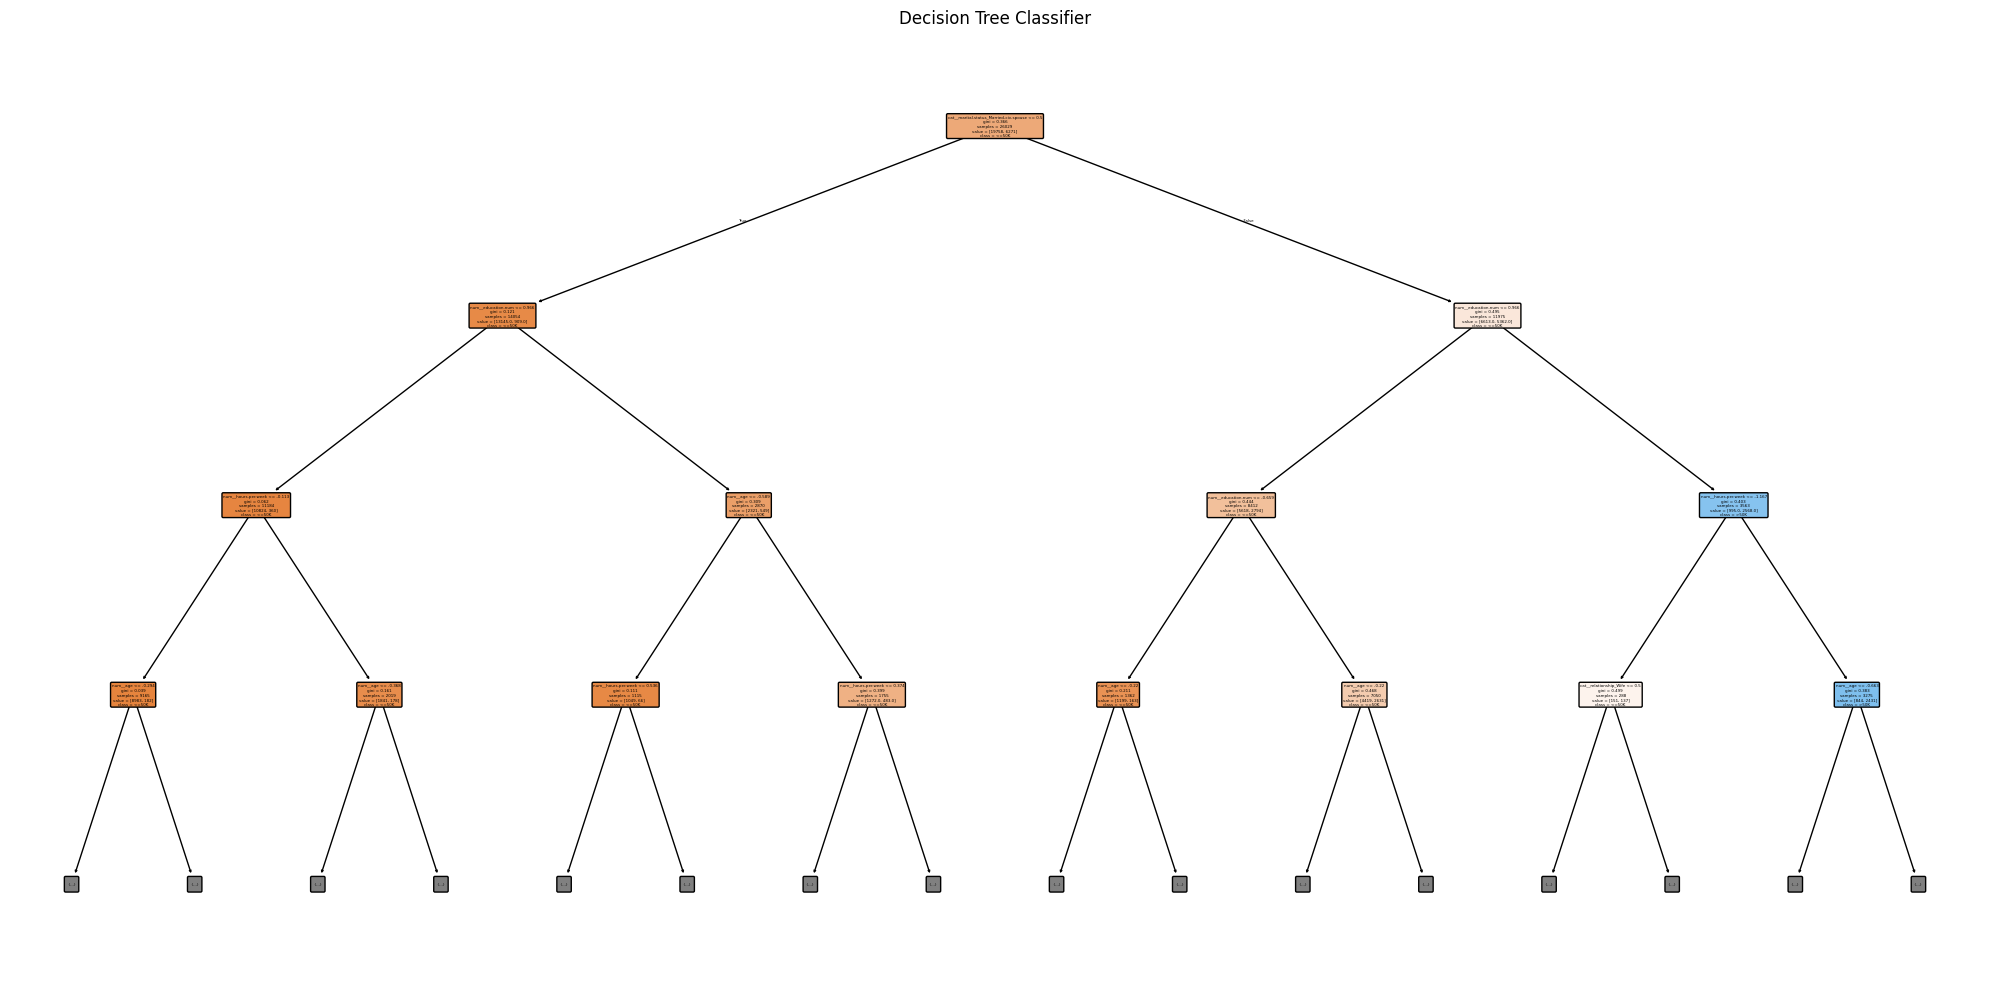

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    max_depth=3,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()

### Observation – Decision Tree Visualization

The Decision Tree visualization shows the hierarchical decision-making process used by the classifier. Starting from the root node, the observations are progressively divided based on feature conditions until they reach the leaf nodes representing the predicted income classes.

The visualization provides an interpretable representation of how the model separates the two income classes. Only the first few levels are displayed to keep the visualization clear and readable, while the final trained model uses the selected `max_depth`.

## D1.5 Support Vector Machine (SVC)

Support Vector Machine (SVM) is a supervised classification algorithm that finds a decision boundary that separates observations belonging to different classes.

The SVC implementation is used for the Adult income classification problem. The `C` parameter controls the trade-off between achieving a wider decision boundary and correctly classifying the training observations, while the kernel determines the type of decision boundary used by the model.

Different values of `C` and kernel types are tested to identify a suitable configuration for the classification task.

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Values of C and kernel to test
C_values = [0.1, 1]
kernel_values = ["linear", "rbf"]

svm_results = []

for C in C_values:
    for kernel in kernel_values:

        svm_model_temp = SVC(
            C=C,
            kernel=kernel,
            random_state=42
        )

        svm_model_temp.fit(X_train_processed, y_train)

        y_pred_svm_temp = svm_model_temp.predict(X_test_processed)

        accuracy = accuracy_score(y_test, y_pred_svm_temp)

        svm_results.append({
            "C": C,
            "Kernel": kernel,
            "Accuracy": accuracy
        })

svm_results_df = pd.DataFrame(svm_results)

display(svm_results_df)

,C,Kernel,Accuracy
0,0.1,linear,0.831285
1,0.1,rbf,0.827597
2,1.0,linear,0.832053
3,1.0,rbf,0.834972


In [50]:
# Select the best SVM configuration based on accuracy

best_svm_row = svm_results_df.loc[
    svm_results_df["Accuracy"].idxmax()
]

best_C = best_svm_row["C"]
best_kernel = best_svm_row["Kernel"]

print("Best C:", best_C)
print("Best kernel:", best_kernel)
print("Best accuracy:", best_svm_row["Accuracy"])

Best C: 1.0
Best kernel: rbf
Best accuracy: 0.8349723417332514


### Observation – SVM Tuning

The SVM classifier was evaluated using different combinations of the `C` parameter and kernel type. The results show that the choice of these parameters affects the classification performance.

Among the tested configurations, `C = 1.0` with the RBF kernel achieved the highest accuracy of 0.834972, approximately 83.50%. Therefore, this configuration was selected for training the final SVM model.

The RBF kernel was able to provide the best performance among the tested kernel configurations, indicating that a nonlinear decision boundary was more suitable for separating the income classes in the tested configurations.

In [51]:
# Train the final SVM model using the selected parameters

svm_model = SVC(
    C=best_C,
    kernel=best_kernel,
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

y_pred_svm = svm_model.predict(X_test_processed)

print("Final SVM model trained successfully.")
print("Selected C:", best_C)
print("Selected kernel:", best_kernel)
print("Predictions generated successfully.")

Final SVM model trained successfully.
Selected C: 1.0
Selected kernel: rbf
Predictions generated successfully.


### Observation – Final SVM Model

The final SVM model was trained using `C = 1.0` and the RBF kernel, which produced the highest accuracy during the parameter tuning stage. Predictions were successfully generated for the test dataset.

The trained model will be evaluated along with the other Part-A classification algorithms using the required evaluation metrics.

## D2. Evaluation of Part-A Classification Models

The five Part-A classification algorithms are evaluated using Accuracy and weighted F1-score. Confusion matrices are also generated for each algorithm to examine the distribution of correct and incorrect predictions across the two income classes.

The same test dataset is used for all five algorithms so that their performance can be compared fairly.

In [53]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate evaluation metrics for all five models

evaluation_results = []

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_gnb,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm
}

for model_name, predictions in models_predictions.items():

    accuracy = accuracy_score(y_test, predictions)

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    evaluation_results.append({
        "Algorithm": model_name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df)

,Algorithm,Accuracy,Weighted F1
0,Logistic Regression,0.834050,0.827571
1,KNN,0.822526,0.821351
2,Gaussian Naive Bayes,0.517363,0.531109
3,Decision Tree,0.827904,0.824999
4,SVM,0.834972,0.827327


### Observation – Preliminary Model Comparison

The five Part-A classification algorithms were compared using Accuracy and weighted F1-score on the same test dataset.

The results show differences in classification performance among the algorithms. The model with the highest Accuracy and weighted F1-score demonstrates stronger overall classification performance on the test data.

The Accuracy and weighted F1-score results provide an initial basis for comparing the models, while the confusion matrices provide further insight into the correct and incorrect predictions made by each classifier.

In [56]:
# Generate confusion matrices for all five Part-A models

confusion_matrices = {
    "Logistic Regression": confusion_matrix(y_test, y_pred_logistic),
    "KNN": confusion_matrix(y_test, y_pred_knn),
    "Gaussian Naive Bayes": confusion_matrix(y_test, y_pred_gnb),
    "Decision Tree": confusion_matrix(y_test, y_pred_tree),
    "SVM": confusion_matrix(y_test, y_pred_svm)
}

confusion_matrices

{'Logistic Regression': array([[4553,  387],
        [ 693,  875]]),
 'KNN': array([[4392,  548],
        [ 607,  961]]),
 'Gaussian Naive Bayes': array([[1886, 3054],
        [  87, 1481]]),
 'Decision Tree': array([[4452,  488],
        [ 632,  936]]),
 'SVM': array([[4580,  360],
        [ 714,  854]])}

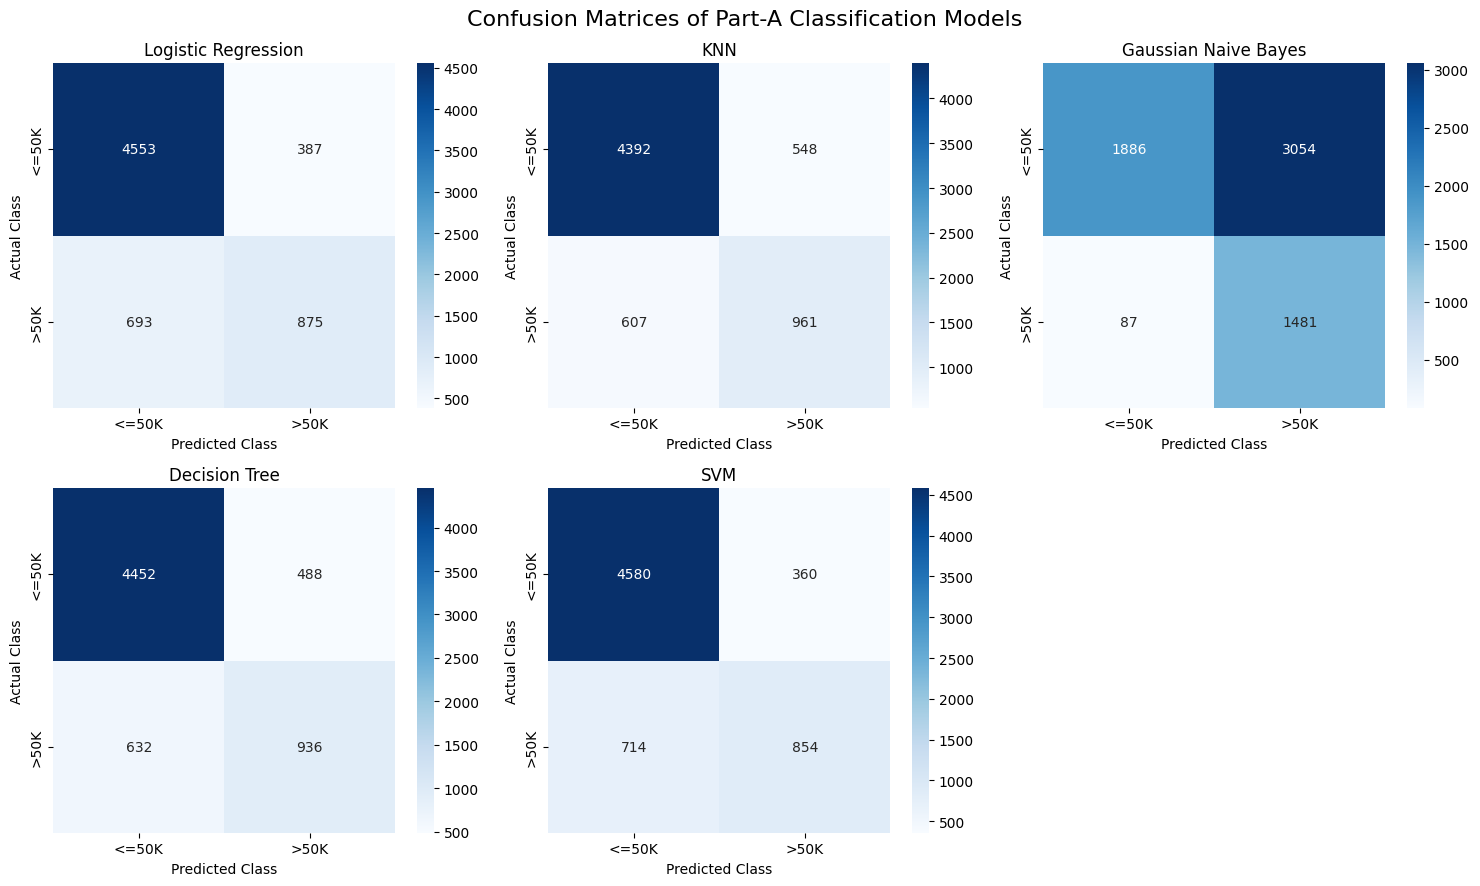

In [57]:
# Plot confusion matrices for all five Part-A models

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

for i, (model_name, cm) in enumerate(confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=axes[i]
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

# Hide the unused sixth subplot
axes[5].axis("off")

fig.suptitle(
    "Confusion Matrices of Part-A Classification Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Observation – Confusion Matrices

The confusion matrices show the correct and incorrect predictions made by each Part-A classifier for the two income classes.

Logistic Regression correctly classified 4553 observations from the `<=50K` class and 875 observations from the `>50K` class. It produced 387 false positives and 693 false negatives.

KNN correctly classified 4392 `<=50K` observations and 961 `>50K` observations. Compared with Logistic Regression, KNN identified more observations from the `>50K` class correctly, but also produced more false positives.

Gaussian Naive Bayes showed a different prediction pattern. It correctly classified 1886 `<=50K` observations and 1481 `>50K` observations, but produced a large number of false positives (3054). This is consistent with its substantially lower Accuracy and weighted F1-score.

Decision Tree correctly classified 4452 `<=50K` observations and 936 `>50K` observations, with 488 false positives and 632 false negatives. Its errors were relatively balanced compared with the other models.

SVM correctly classified the largest number of `<=50K` observations, with 4580 correct predictions, and produced the fewest false positives (360). However, it correctly classified 854 `>50K` observations and produced 714 false negatives.

Overall, the confusion matrices show that the models differ in how they handle the two income classes. SVM produced the strongest overall accuracy among the five models, while KNN and Decision Tree correctly identified more `>50K` observations than SVM. Gaussian Naive Bayes showed the weakest overall prediction pattern because of its high number of false-positive predictions.

In [59]:
# Rank the Part-A models based on Accuracy

preliminary_comparison = evaluation_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

preliminary_comparison.insert(
    0,
    "Rank",
    range(1, len(preliminary_comparison) + 1)
)

display(preliminary_comparison)

,Rank,Algorithm,Accuracy,Weighted F1
0,1,SVM,0.834972,0.827327
1,2,Logistic Regression,0.834050,0.827571
2,3,Decision Tree,0.827904,0.824999
3,4,KNN,0.822526,0.821351
4,5,Gaussian Naive Bayes,0.517363,0.531109


### Observation – Preliminary Comparison

Based on the preliminary comparison, SVM achieved the highest Accuracy among the five Part-A algorithms, followed closely by Logistic Regression. Decision Tree and KNN showed moderate performance, while Gaussian Naive Bayes performed substantially lower on both Accuracy and weighted F1-score.

Although SVM achieved the highest Accuracy, Logistic Regression obtained a slightly higher weighted F1-score than SVM. Therefore, both metrics are considered when comparing the models rather than relying on Accuracy alone.

These results provide a preliminary comparison of the Part-A algorithms. A final model selection will be performed later after evaluating all ten classification algorithms.